## Imports and Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Physical constants
rho = 1.225          # air density at sea level [kg/m^3]
V = 230.0            # cruise speed [m/s]
e = 0.8              # Oswald efficiency factor
W = 7.0e5            # aircraft weight [N]
k_f = 0.45           # fuel volume efficiency coefficient
k_c = 0.60           # cargo volume efficiency coefficient

# Minimum requirements
V_fuel_min = 80.0    # minimum fuel volume [m^3]
V_cargo_min = 120.0  # minimum cargo volume [m^3]
AR_min = 6.0
AR_max = 14.0
S_w_min = 80.0
S_w_max = 300.0

# Design variable bounds
# x = [b, S_w, sweep, t_c, L_f, D_f]
X_MIN = np.array([30.0, 60.0, 0.0, 0.08, 25.0, 3.0])
X_MAX = np.array([60.0, 350.0, 40.0, 0.20, 50.0, 6.0])

## Aircraft Model

In [21]:
def evaluate_aircraft(x):
    b, S_w, sweep, t_c, L_f, D_f = x
    AR = b**2 / S_w
    C_L = 2 * W / (rho * V**2 * S_w)
    C_D0 = 0.018 + 0.002 * (D_f / L_f) + 0.0001 * abs(sweep)
    C_Di = C_L**2 / (np.pi * e * AR)
    C_D = C_D0 + C_Di
    c_bar = S_w / b
    V_fuel = k_f * S_w * c_bar * t_c
    V_cargo = k_c * L_f * D_f
    return C_D, V_fuel, V_cargo, AR

## Penalty

In [16]:
def constraint_penalty(x):
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    b, S_w, sweep, t_c, L_f, D_f = x
    violations = [
        max(0, V_fuel_min - V_fuel),
        max(0, V_cargo_min - V_cargo),
        max(0, AR_min - AR),
        max(0, AR - AR_max),
        max(0, S_w_min - S_w),
        max(0, S_w - S_w_max),
    ]
    return sum(v**2 for v in violations)

## Objective Operators

In [17]:
def objective_function(x, penalty_weight=1e3):
    """
    Multi-objective function converted into a penalized vector.
    Objectives: minimize drag, maximize fuel volume, maximize cargo volume.
    """
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    penalty = constraint_penalty(x)
    return np.array([
        C_D + penalty_weight * penalty,
        -V_fuel + penalty_weight * penalty,
        -V_cargo + penalty_weight * penalty,
    ])

## Genetic Algorithm

In [18]:
def dominates(F_a, F_b):
    # check if F_a domintes F_b
    at_least_one_less = np.any(F_a < F_b)
    all_less_equal = np.all(F_a <= F_b)
    return at_least_one_less and all_less_equal


def get_pareto_front(population, objectives):
    pareto_indices = []
    N = len(population)
    
    for i in range(N):
        is_dominated = False
        for j in range(N):
            if i != j and dominates(objectives[j], objectives[i]):
                is_dominated = True
                break
        if not is_dominated:
            pareto_indices.append(i)
    
    return population[pareto_indices], objectives[pareto_indices]


def crossover(x1, x2, crossover_prob=0.8):
    if np.random.rand() < crossover_prob:
        mask = np.random.randint(0, 2, size=len(x1))
        return np.where(mask, x1, x2), np.where(1 - mask, x1, x2)
    else:
        return x1.copy(), x2.copy()


def mutation(x, mutation_prob=0.1, mutation_strength=0.15):
    # Add random to genes
    mutant = x.copy()
    for i in range(len(x)):
        if np.random.rand() < mutation_prob:
            noise = np.random.normal(0, mutation_strength * (X_MAX[i] - X_MIN[i]))
            mutant[i] += noise
    
    # Clip to bounds
    return np.clip(mutant, X_MIN, X_MAX)

In [19]:
class MultiObjectiveGeneticAlgorithm:    
    def __init__(self, population_size=50, generations=100):
        self.population_size = population_size
        self.generations = generations
        self.population = None
        self.objectives = None
        self.pareto_front_history = []
    
    def initialize_population(self):
        self.population = np.random.uniform(X_MIN, X_MAX, (self.population_size, len(X_MIN)))
    
    def evaluate_population(self):
        self.objectives = np.array([objective_function(x) for x in self.population])
    
    def selection(self):
        selected = []
        for _ in range(self.population_size):
            # Random tournament between 3 individuals (select best)
            indices = np.random.choice(self.population_size, 3, replace=False)
            # Pick the one with lowest aggregated objective
            scores = [np.sum(self.objectives[i]) for i in indices]
            winner = indices[np.argmin(scores)]
            selected.append(self.population[winner].copy())
        return np.array(selected)
    
    def evolve(self):
        print("Initializing population...")
        self.initialize_population()
        self.evaluate_population()
        
        for generation in range(self.generations):
            # Selection
            selected_pop = self.selection()
            
            # Crossover and mutation
            new_population = []
            for i in range(0, self.population_size, 2):
                parent1 = selected_pop[i]
                parent2 = selected_pop[(i + 1) % self.population_size]
                child1, child2 = crossover(parent1, parent2)
                child1 = mutation(child1)
                child2 = mutation(child2)
                new_population.extend([child1, child2])
            
            self.population = np.array(new_population[:self.population_size])
            self.evaluate_population()
            
            # Track Pareto front
            pareto_pop, pareto_obj = get_pareto_front(self.population, self.objectives)
            self.pareto_front_history.append(len(pareto_pop))
            
            if (generation + 1) % 20 == 0:
                print(f"Generation {generation + 1}/{self.generations}: Pareto front size = {len(pareto_pop)}")
        
        print("Optimization complete!")
        pareto_pop, pareto_obj = get_pareto_front(self.population, self.objectives)
        return pareto_pop, pareto_obj

## Output and Visualization

Initializing population...
Generation 20/100: Pareto front size = 2
Generation 40/100: Pareto front size = 32
Generation 60/100: Pareto front size = 38
Generation 80/100: Pareto front size = 33
Generation 100/100: Pareto front size = 35
Optimization complete!

Pareto front size: 35

Pareto Front Solutions:
------------------------------------------------------------------------------------------
Sol  Drag       Fuel [m³]    Cargo [m³]   AR       Feasible  
------------------------------------------------------------------------------------------
1    0.0186     180.88       180.00       5.99     ✓         
2    0.0186     180.88       180.00       5.99     ✓         
3    0.0186     170.24       180.00       6.77     ✓         
4    0.0186     180.88       169.30       5.99     ✓         
5    0.0186     180.88       180.00       5.99     ✓         
6    0.0186     183.32       180.00       5.95     ✗         
7    0.0186     180.88       180.00       5.99     ✓         
8    0.0186   

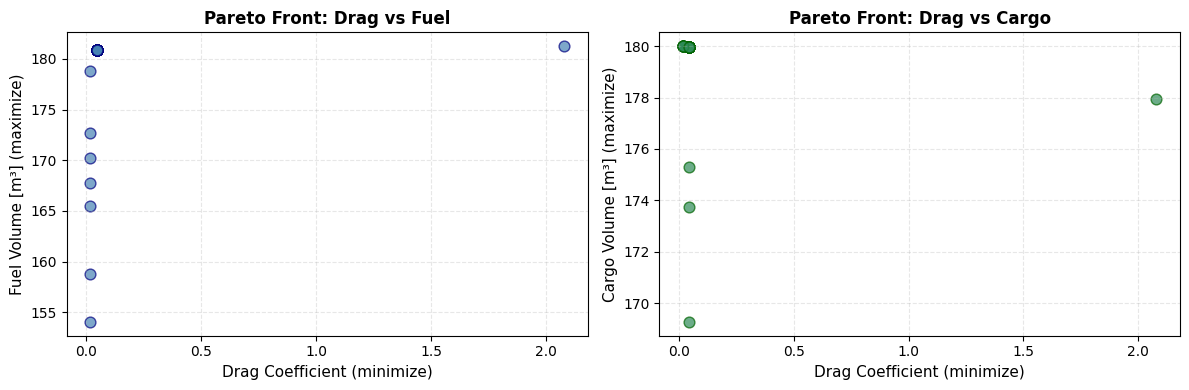

In [22]:
def plot_pareto_front(pareto_pop):
    objectives = np.array([objective_function(x) for x in pareto_pop])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].scatter(objectives[:, 0], -objectives[:, 1], s=60, alpha=0.7, color='steelblue', edgecolors='navy')
    axes[0].set_xlabel('Drag Coefficient (minimize)', fontsize=11)
    axes[0].set_ylabel('Fuel Volume [m³] (maximize)', fontsize=11)
    axes[0].set_title('Pareto Front: Drag vs Fuel', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, linestyle='--')
    
    axes[1].scatter(objectives[:, 0], -objectives[:, 2], s=60, alpha=0.7, color='seagreen', edgecolors='darkgreen')
    axes[1].set_xlabel('Drag Coefficient (minimize)', fontsize=11)
    axes[1].set_ylabel('Cargo Volume [m³] (maximize)', fontsize=11)
    axes[1].set_title('Pareto Front: Drag vs Cargo', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()


optimizer = MultiObjectiveGeneticAlgorithm(population_size=50, generations=100)
pareto_population, pareto_objectives = optimizer.evolve()

print(f"\nPareto front size: {len(pareto_population)}")

solutions = []
for x in pareto_population:
    C_D, V_fuel, V_cargo, AR = evaluate_aircraft(x)
    penalty = constraint_penalty(x)
    is_feasible = penalty < 1e-3
    solutions.append({
        'x': x,
        'C_D': C_D,
        'V_fuel': V_fuel,
        'V_cargo': V_cargo,
        'AR': AR,
        'penalty': penalty,
        'feasible': is_feasible
    })

print("\nPareto Front Solutions:")
print("-" * 90)
print(f"{'Sol':<4} {'Drag':<10} {'Fuel [m³]':<12} {'Cargo [m³]':<12} {'AR':<8} {'Feasible':<10}")
print("-" * 90)
for i, sol in enumerate(solutions, 1):
    status = "✓" if sol['feasible'] else "✗"
    print(f"{i:<4} {sol['C_D']:<10.4f} {sol['V_fuel']:<12.2f} {sol['V_cargo']:<12.2f} {sol['AR']:<8.2f} {status:<10}")

plot_pareto_front(pareto_population)